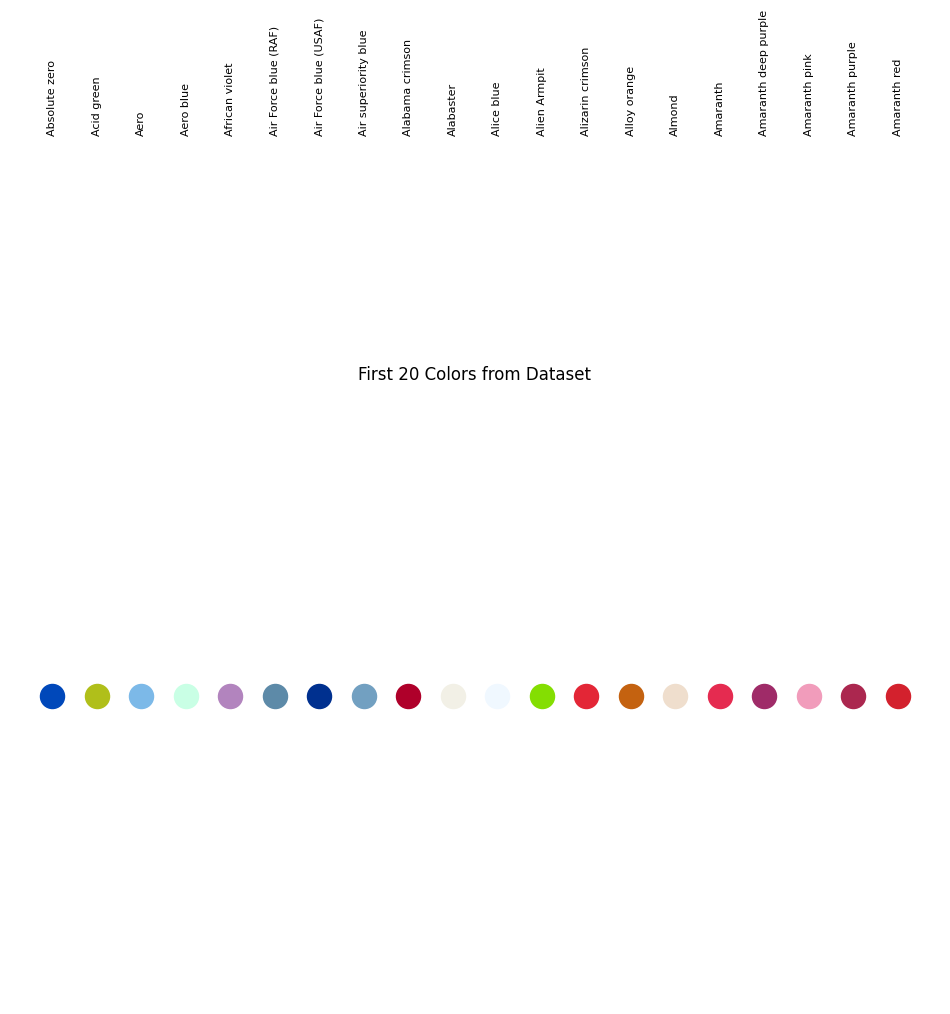

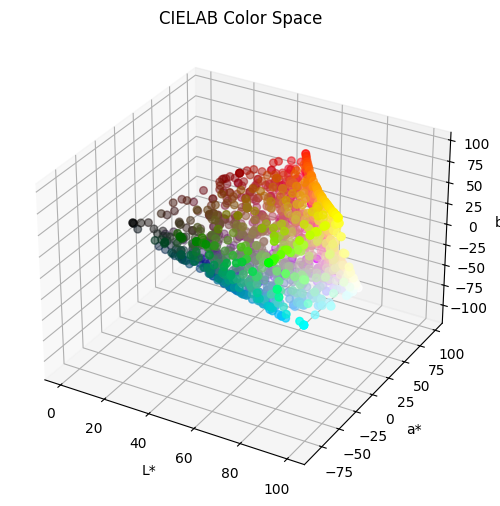

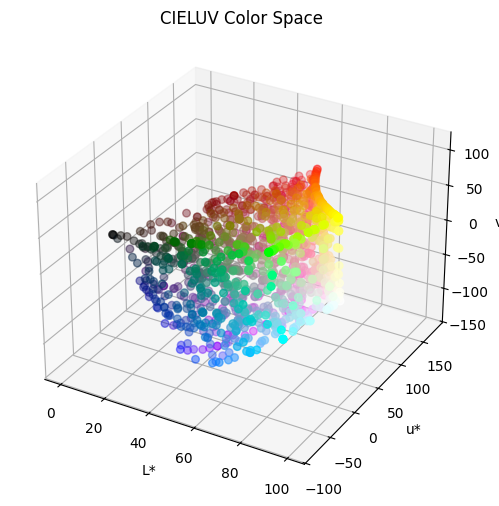

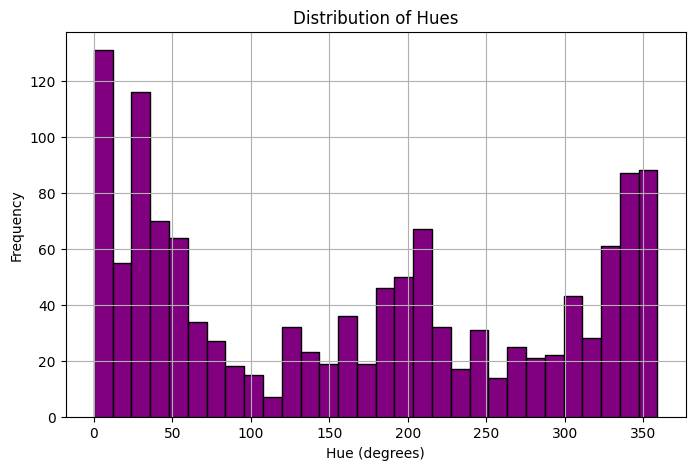

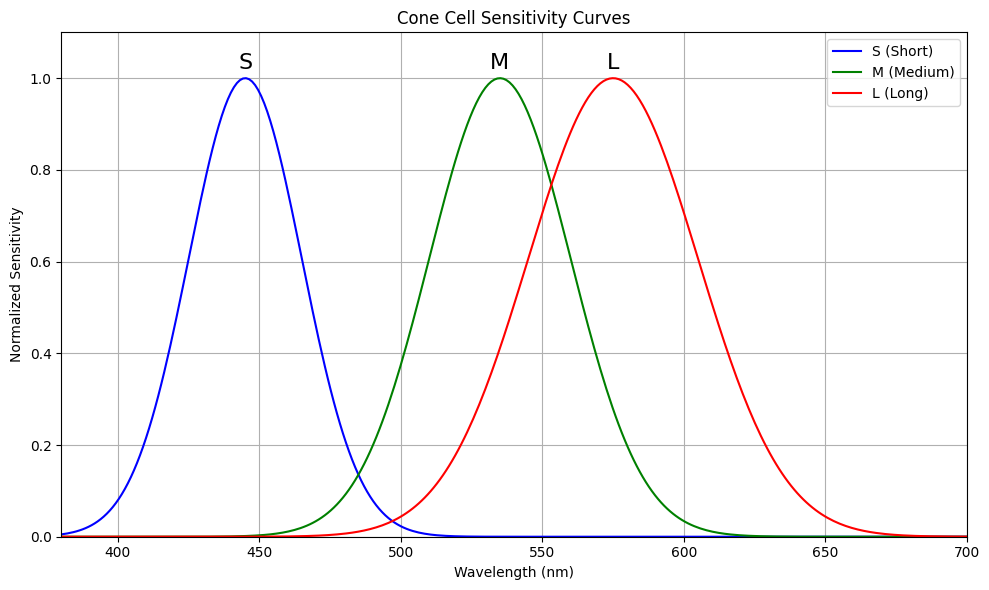

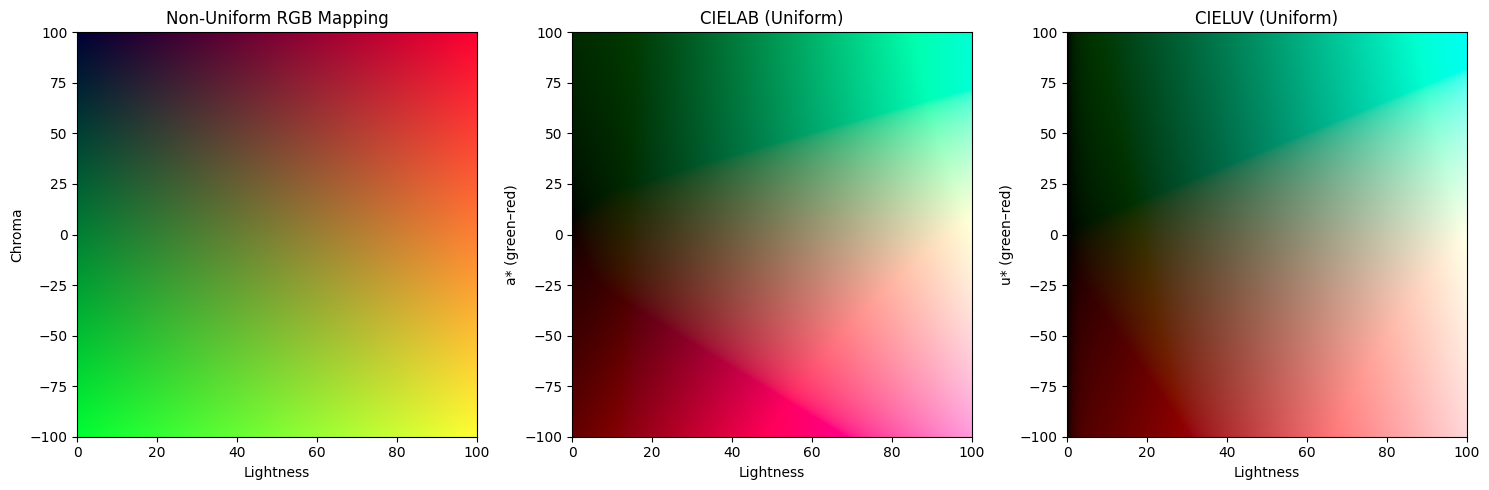

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage.color import rgb2lab, rgb2luv, lab2rgb, luv2rgb

df = pd.read_csv('Datasets/color_names.csv')

rgb = df[['Red (8 bit)', 'Green (8 bit)', 'Blue (8 bit)']].values / 255.0

lab = rgb2lab(rgb.reshape(1, -1, 3)).reshape(-1, 3)
luv = rgb2luv(rgb.reshape(1, -1, 3)).reshape(-1, 3)

# Add to DataFrame
df[['L_lab', 'A_lab', 'B_lab']] = lab
df[['L_luv', 'U_luv', 'V_luv']] = luv

plt.figure(figsize=(12, 8))
for i in range(20):  # Show first 20 colors
    color = rgb[i]
    plt.scatter(i, 1, color=color, s=300)
    plt.text(i, 1.1, df['Name'][i], rotation=90, ha='center', va='bottom', fontsize=8)
plt.axis('off')
plt.title("First 20 Colors from Dataset")
plt.show()

#LAB 3D plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['L_lab'], df['A_lab'], df['B_lab'], c=rgb, s=30)
ax.set_xlabel('L*')
ax.set_ylabel('a*')
ax.set_zlabel('b*')
ax.set_title('CIELAB Color Space')
plt.show()

#LUV 3D plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['L_luv'], df['U_luv'], df['V_luv'], c=rgb, s=30)
ax.set_xlabel('L*')
ax.set_ylabel('u*')
ax.set_zlabel('v*')
ax.set_title('CIELUV Color Space')
plt.show()

#Hue histogram
plt.figure(figsize=(8, 5))
plt.hist(df['Hue (degrees)'].dropna(), bins=30, color='purple', edgecolor='black')
plt.xlabel('Hue (degrees)')
plt.ylabel('Frequency')
plt.title('Distribution of Hues')
plt.grid(True)
plt.show()

#Cone cell simulation (S, M, L sensitivity)
wavelengths = np.linspace(380, 700, 300)
S = np.exp(-0.5 * ((wavelengths - 445) / 20)**2)
M = np.exp(-0.5 * ((wavelengths - 535) / 25)**2)
L = np.exp(-0.5 * ((wavelengths - 575) / 30)**2)

S /= S.max()
M /= M.max()
L /= L.max()

plt.figure(figsize=(10, 6))
plt.plot(wavelengths, S, color='blue', label='S (Short)')
plt.plot(wavelengths, M, color='green', label='M (Medium)')
plt.plot(wavelengths, L, color='red', label='L (Long)')
plt.text(445, 1.02, 'S', fontsize=16, ha='center')
plt.text(535, 1.02, 'M', fontsize=16, ha='center')
plt.text(575, 1.02, 'L', fontsize=16, ha='center')
plt.ylim(0, 1.1)
plt.xlim(380, 700)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Sensitivity')
plt.title('Cone Cell Sensitivity Curves')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

#Uniformity comparison: LAB vs LUV vs RGB-like mapping

#Create a grid of values
L_vals = np.linspace(0, 100, 300)
chroma_vals = np.linspace(-100, 100, 300)
L_grid, chroma_grid = np.meshgrid(L_vals, chroma_vals)

#Flatten grids for vectorized operations
L_flat = L_grid.flatten()
C_flat = chroma_grid.flatten()

#Set fixed chromatic axis values
b_fixed = 20
v_fixed = 20

#Create LAB and LUV arrays for conversion
lab_array = np.stack([L_flat, C_flat, np.full_like(L_flat, b_fixed)], axis=1)
luv_array = np.stack([L_flat, C_flat, np.full_like(L_flat, v_fixed)], axis=1)

#Reshape to image format after conversion
lab_rgb = lab2rgb(lab_array.reshape(300, 300, 3))
luv_rgb = luv2rgb(luv_array.reshape(300, 300, 3))

#Simulated RGB mapping for comparison (just mapping values, not perceptually uniform)
rgb_img = np.stack([
    L_grid / 100,                         
    (chroma_grid + 100) / 200,            
    np.full_like(L_grid, b_fixed / 100)   
], axis=2)
rgb_img = np.clip(rgb_img, 0, 1)

# Plot the three images
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(rgb_img, extent=[0, 100, -100, 100], aspect='auto')
axs[0].set_title("Non-Uniform RGB Mapping")
axs[0].set_xlabel("Lightness")
axs[0].set_ylabel("Chroma")

axs[1].imshow(lab_rgb, extent=[0, 100, -100, 100], aspect='auto')
axs[1].set_title("CIELAB (Uniform)")
axs[1].set_xlabel("Lightness")
axs[1].set_ylabel("a* (green–red)")

axs[2].imshow(luv_rgb, extent=[0, 100, -100, 100], aspect='auto')
axs[2].set_title("CIELUV (Uniform)")
axs[2].set_xlabel("Lightness")
axs[2].set_ylabel("u* (green–red)")

plt.tight_layout()
plt.show()
